In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = datasets.ImageFolder(r"C:\Users\akrit\OneDrive\My Datasets\archive\chest_xray\train", transform=transform)
test_dataset = datasets.ImageFolder(r"C:\Users\akrit\OneDrive\My Datasets\archive\chest_xray\test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['NORMAL', 'PNEUMONIA']


In [7]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for 2 classes
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [9]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}, Accuracy: {100 * correct / total:.2f}%")

Epoch [1/10], Loss: 42.0757, Accuracy: 89.44%
Epoch [2/10], Loss: 27.5426, Accuracy: 93.25%
Epoch [3/10], Loss: 23.9578, Accuracy: 94.36%
Epoch [4/10], Loss: 22.0691, Accuracy: 94.67%
Epoch [5/10], Loss: 19.9465, Accuracy: 95.26%
Epoch [6/10], Loss: 21.0704, Accuracy: 95.02%
Epoch [7/10], Loss: 18.7484, Accuracy: 95.57%
Epoch [8/10], Loss: 18.3833, Accuracy: 95.67%
Epoch [9/10], Loss: 16.9696, Accuracy: 96.18%
Epoch [10/10], Loss: 16.5398, Accuracy: 95.86%


In [10]:
model.eval()
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

In [11]:
print(classification_report(all_labels, all_preds))

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print("Accuracy:", accuracy)

auc = roc_auc_score(all_labels, all_probs)
print("AUC:", auc)

              precision    recall  f1-score   support

           0       0.96      0.41      0.57       234
           1       0.74      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.85      0.70      0.71       624
weighted avg       0.82      0.77      0.74       624

Accuracy: 0.7708333333333334
AUC: 0.9365768134998904


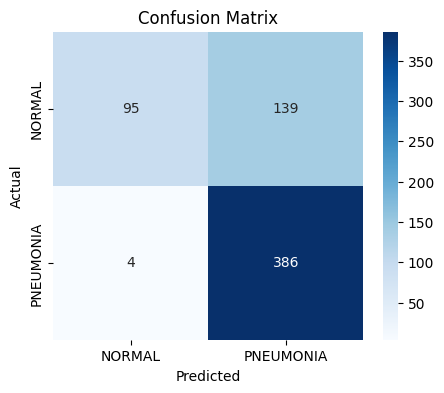

In [12]:

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

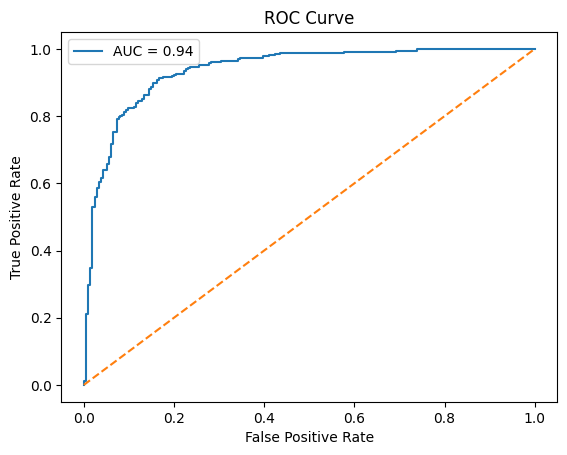

In [13]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()